# Exploratory Data Analysis

Full EDA covering Constructor Dominance, Grid vs Finish predictability, and Driver Transfers.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../final_datasets/f1_unified_dataset_1950_2025.csv')

# Configure styling
sns.set_theme(style='darkgrid', palette='deep')

## RQ1: Constructor Dominance

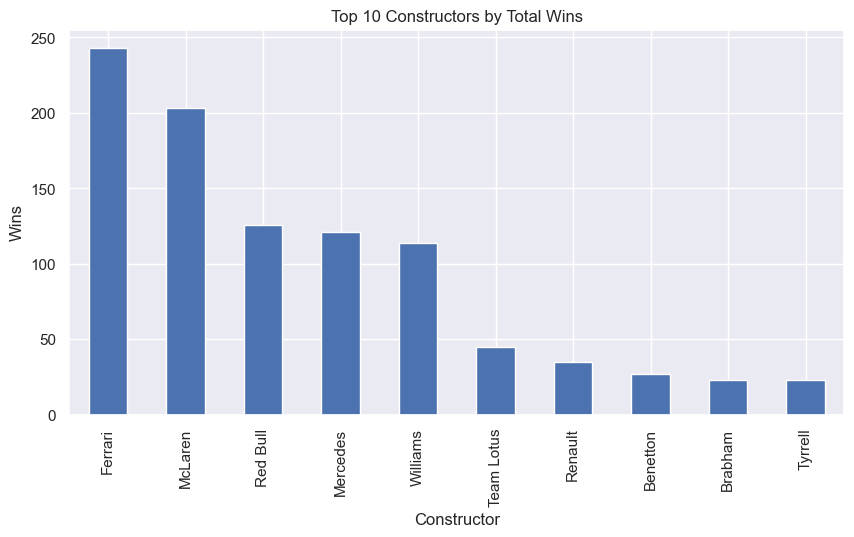

In [2]:
wins_df = pd.read_csv('../final_datasets/rq1_constructor_dominance.csv')
top_constructors = wins_df.groupby('Constructor')['Win'].sum().nlargest(10)
top_constructors.plot(kind='bar', figsize=(10, 5), title='Top 10 Constructors by Total Wins')
plt.ylabel('Wins')
plt.show()

## RQ2: Grid vs Finish Predictability

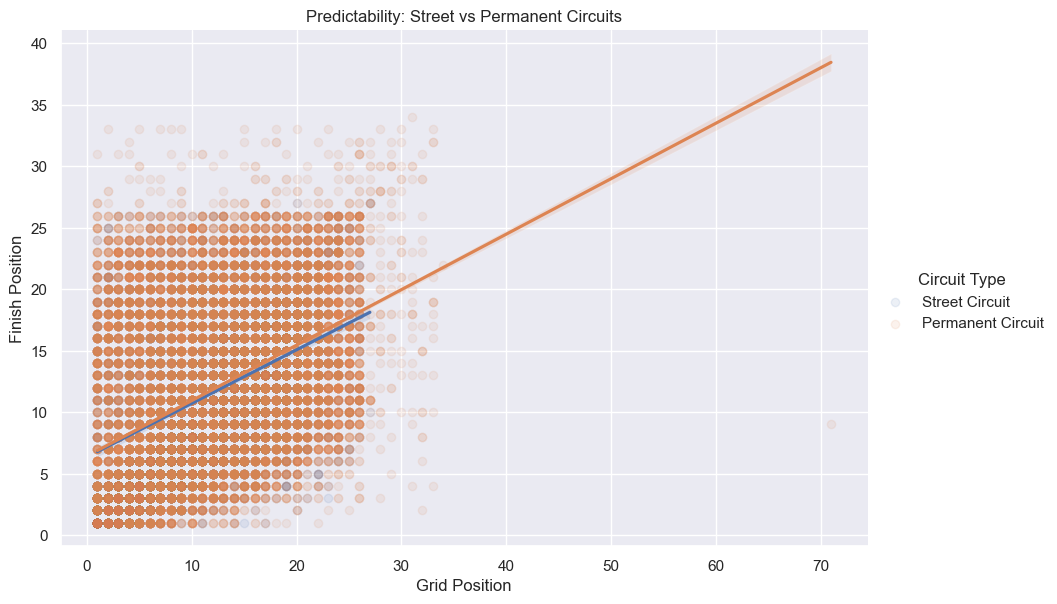

In [3]:
rq2 = pd.read_csv('../final_datasets/rq2_grid_finish_circuits.csv')
sns.lmplot(data=rq2, x='Grid Position', y='Finish Position', hue='Circuit Type', scatter_kws={'alpha':0.1}, height=6, aspect=1.5)
plt.title('Predictability: Street vs Permanent Circuits')
plt.show()

## RQ3: Driver Transfers Overview

In [4]:
rq3 = pd.read_csv('../final_datasets/rq3_driver_transfers.csv')
driver_counts = rq3.groupby('Driver')['Constructor'].nunique().sort_values(ascending=False)
print('Drivers with most team transfers:')
print(driver_counts.head(10))

Drivers with most team transfers:
Driver
Chris Amon             14
Maurice Trintignant    13
Stirling Moss          12
Jean-Pierre Jarier     11
Andrea de Cesaris      10
Roy Salvadori          10
Stefan Johansson       10
Jo Bonnier             10
Jacky Ickx             10
Dan Gurney             10
Name: Constructor, dtype: int64


## Constructor Points Histogram
Histogram of constructor points for Ferrari, McLaren, Red Bull, Mercedes, and Renault from 1950 to present.

In [10]:
CONSTRUCTOR_MAP = {
    # Ferrari
    "Ferrari": "Ferrari",
 
    # McLaren
    "McLaren": "McLaren",
 
    # Mercedes
    "Mercedes": "Mercedes",
 
    # Red Bull family
    "Red Bull": "Red Bull",
    "RB": "Red Bull",
    "Toro Rosso": "Red Bull (Feeder)",
    "Racing Bulls": "Red Bull (Feeder)",
    "Scuderia Toro Rosso Honda": "Red Bull (Feeder)",
 
    # Williams
    "Williams": "Williams",
 
    # Renault lineage (see module docstring)
    "Renault": "Renault / Alpine",
    "Lotus F1": "Renault / Alpine",   # 2012–2015 era
    "Alpine": "Renault / Alpine",
 
    # Original Lotus / Team Lotus (Colin Chapman era)
    "Lotus": "Lotus (Chapman)",
    "Team Lotus": "Lotus (Chapman)",
    "Lotus-Climax": "Lotus (Chapman)",
    "Lotus-Ford": "Lotus (Chapman)",
    "Lotus-BRM": "Lotus (Chapman)",
    "Lotus-Maserati": "Lotus (Chapman)",
 
    # Brabham
    "Brabham": "Brabham",
    "Brabham-Ford": "Brabham",
    "Brabham-Repco": "Brabham",
    "Brabham-Climax": "Brabham",
    "Brabham-BRM": "Brabham",
    "Brabham-Alfa Romeo": "Brabham",
 
    # Benetton → morphed into Renault 2002
    "Benetton": "Benetton",
 
    # Others worth tracking
    "Alfa Romeo": "Alfa Romeo",
    "Brawn": "Brawn GP",
    "Haas": "Haas",
    "Aston Martin": "Aston Martin",
    "Mclaren": "McLaren",          # typo guard
}
 
LEGACY_TEAMS = [
    "Ferrari", "McLaren", "Mercedes", "Red Bull",
    "Williams", "Renault / Alpine", "Lotus (Chapman)",
    "Brabham", "Benetton", "Alfa Romeo", "Brawn GP"
]
 
df["Canon"] = df["Constructor"].map(CONSTRUCTOR_MAP)

In [11]:
# ─────────────────────────────────────────────────────────────
# 2. RENAULT LINEAGE GAP ANALYSIS
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("RENAULT LINEAGE: RAW YEAR PRESENCE IN DATA")
print("=" * 60)
renault_raw = df[df["Constructor"].isin(["Renault", "Lotus F1", "Alpine"])].copy()
for name in ["Renault", "Lotus F1", "Alpine"]:
    years = sorted(df[df["Constructor"] == name]["Year"].unique())
    if years:
        print(f"  {name:12s}: {min(years)}–{max(years)}  ({len(years)} seasons present)")
print()

RENAULT LINEAGE: RAW YEAR PRESENCE IN DATA
  Renault     : 1977–2020  (23 seasons present)
  Lotus F1    : 2012–2015  (4 seasons present)
  Alpine      : 2021–2026  (6 seasons present)



In [16]:
print("=" * 60)
print("RENAULT LINEAGE: POINTS & WINS BY BRANDING ERA")
print("=" * 60)
renault_eras = {
    "Renault Mk1 (1977–1985)": ("Renault", range(1977, 1986)),
    "Renault Inactive (1986-2001)": ("Renault", range(1986, 2002)),
    "Renault Mk2 (2002–2011)": ("Renault", range(2002, 2012)),
    "Lotus F1 (2012–2015)":    ("Lotus F1", range(2012, 2016)),
    "Renault Mk3 (2016–2020)": ("Renault", range(2016, 2021)),
    "Alpine (2021–now)":       ("Alpine", range(2021, 2026)),
}
for era_label, (constructor, years) in renault_eras.items():
    era_df = df[(df["Constructor"] == constructor) & (df["Year"].isin(years))]
    pts   = era_df["Points"].sum()
    wins  = (era_df["Finish Position"] == 1.0).sum()
    races = era_df["Race Name"].nunique()
    print(f"  {era_label}")
    print(f"    Points: {pts:.0f}  |  Wins: {wins}  |  Unique races contested: {races}")
print()

RENAULT LINEAGE: POINTS & WINS BY BRANDING ERA
  Renault Mk1 (1977–1985)
    Points: 312  |  Wins: 15  |  Unique races contested: 24
  Renault Inactive (1986-2001)
    Points: 0  |  Wins: 0  |  Unique races contested: 0
  Renault Mk2 (2002–2011)
    Points: 1006  |  Wins: 20  |  Unique races contested: 24
  Lotus F1 (2012–2015)
    Points: 706  |  Wins: 2  |  Unique races contested: 23
  Renault Mk3 (2016–2020)
    Points: 337  |  Wins: 0  |  Unique races contested: 51
  Alpine (2021–now)
    Points: 518  |  Wins: 1  |  Unique races contested: 30



In [26]:
for year in range(2012, 2016):
    print(year)
    print(df[(df["Constructor"] == 'Lotus F1') & (df["Year"]== year)]['Points'].sum())

2012
303.0
2013
315.0
2014
10.0
2015
78.0


In [13]:
name = 'Lotus (Chapman)'
years = sorted(df[df["Canon"] == name]["Year"].unique())
print(f"  {name:12s}: {min(years)}–{max(years)}  ({len(years)} seasons present)")

  Lotus (Chapman): 1958–2011  (39 seasons present)


In [7]:
season_pts = (
    df[df["Canon"].isin(LEGACY_TEAMS)]
    .groupby(["Year", "Canon"])["Points"]
    .sum()
    .reset_index()
    .rename(columns={"Points": "SeasonPoints"})
)
 
print("=" * 60)
print("TOP SEASONS BY CONSTRUCTOR POINTS (Legacy teams)")
print("=" * 60)
top = season_pts.sort_values("SeasonPoints", ascending=False).head(20)
print(top.to_string(index=False))
print()

TOP SEASONS BY CONSTRUCTOR POINTS (Legacy teams)
 Year    Canon  SeasonPoints
 2023 Red Bull         812.0
 2025  McLaren         775.0
 2016 Mercedes         765.0
 2022 Red Bull         759.0
 2019 Mercedes         739.0
 2021 Red Bull         720.5
 2015 Mercedes         703.0
 2014 Mercedes         701.0
 2017 Mercedes         668.0
 2011 Red Bull         650.0
 2024  McLaren         609.0
 2021 Mercedes         604.5
 2013 Red Bull         596.0
 2024  Ferrari         595.0
 2024 Red Bull         577.0
 2020 Mercedes         573.0
 2017  Ferrari         522.0
 2022  Ferrari         519.0
 2019  Ferrari         504.0
 2010 Red Bull         498.0



In [8]:
wins = (
    df[df["Finish Position"] == 1.0]
    .groupby("Canon")
    .size()
    .reset_index(name="Wins")
)
total_pts = (
    df.groupby("Canon")["Points"]
    .sum()
    .reset_index(name="TotalPoints")
)
summary = total_pts.merge(wins, on="Canon", how="left").fillna(0)
summary = summary[summary["Canon"].isin(LEGACY_TEAMS)].sort_values("TotalPoints", ascending=False)
 
print("=" * 60)
print("ALL-TIME LEGACY TEAM SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))
print()

ALL-TIME LEGACY TEAM SUMMARY
           Canon  TotalPoints  Wins
         Ferrari     10905.27 243.0
        Red Bull      8022.00 127.0
         McLaren      7895.50 203.0
        Mercedes      7542.64 121.0
        Williams      3758.00 114.0
Renault / Alpine      2880.00  38.0
 Lotus (Chapman)      1514.00  79.0
         Brabham       983.00  35.0
        Benetton       861.50  27.0
      Alfa Romeo       364.00  11.0
        Brawn GP       172.00   8.0



In [14]:
print("=" * 60)
print("LEGACY TEAM LONGEVITY (seasons with ≥1 point)")
print("=" * 60)
longevity = (
    season_pts[season_pts["SeasonPoints"] > 0]
    .groupby("Canon")["Year"]
    .agg(First="min", Last="max", SeasonsWithPoints="count")
    .reset_index()
    .sort_values("SeasonsWithPoints", ascending=False)
)
print(longevity.to_string(index=False))
print()

LEGACY TEAM LONGEVITY (seasons with ≥1 point)
           Canon  First  Last  SeasonsWithPoints
         Ferrari   1950  2026                 76
         McLaren   1966  2026                 60
        Williams   1975  2025                 47
 Lotus (Chapman)   1958  1993                 36
Renault / Alpine   1978  2026                 32
         Brabham   1962  1991                 29
        Red Bull   2005  2026                 21
        Mercedes   1954  2026                 18
        Benetton   1986  2001                 16
      Alfa Romeo   1950  2023                 12
        Brawn GP   2009  2009                  1



In [17]:
print("=" * 60)
print("BIGGEST SINGLE-SEASON POINTS SWINGS (Legacy teams)")
print("=" * 60)
pivot = season_pts.pivot(index="Year", columns="Canon", values="SeasonPoints").fillna(0)
yoy = pivot.diff().stack().reset_index()
yoy.columns = ["Year", "Canon", "PointsDelta"]
 
# Biggest rises
print("  Top 10 RISES:")
rises = yoy[yoy["PointsDelta"] > 0].sort_values("PointsDelta", ascending=False).head(10)
print(rises.to_string(index=False))
print()
print("  Top 10 FALLS:")
falls = yoy[yoy["PointsDelta"] < 0].sort_values("PointsDelta").head(10)
print(falls.to_string(index=False))
print()

BIGGEST SINGLE-SEASON POINTS SWINGS (Legacy teams)
  Top 10 RISES:
 Year            Canon  PointsDelta
 2010          McLaren        383.0
 2010         Red Bull        344.5
 2024          McLaren        343.0
 2014         Mercedes        341.0
 2010          Ferrari        326.0
 2014         Williams        315.0
 2021         Red Bull        294.5
 2016         Red Bull        281.0
 2024          Ferrari        232.0
 2012 Renault / Alpine        230.0

  Top 10 FALLS:
 Year            Canon  PointsDelta
 2026          McLaren       -765.0
 2026         Red Bull       -398.0
 2026         Mercedes       -381.0
 2020          Ferrari       -373.0
 2026          Ferrari       -333.0
 2014 Renault / Alpine       -305.0
 2013          McLaren       -256.0
 2025          Ferrari       -235.0
 2024         Red Bull       -235.0
 2015         Red Bull       -218.0



In [18]:
unique_winners_per_year = (
    df[df["Finish Position"] == 1.0]
    .groupby("Year")["Constructor"]
    .nunique()
    .reset_index(name="UniqueWinners")
)
print("=" * 60)
print("MOST CHAOTIC SEASONS (most unique race winners in a season)")
print("=" * 60)
chaotic = unique_winners_per_year.sort_values("UniqueWinners", ascending=False).head(15)
print(chaotic.to_string(index=False))
print()
 
print("=" * 60)
print("MOST DOMINANT SEASONS (fewest unique race winners)")
print("=" * 60)
mono = unique_winners_per_year.sort_values("UniqueWinners").head(10)
print(mono.to_string(index=False))
print()

MOST CHAOTIC SEASONS (most unique race winners in a season)
 Year  UniqueWinners
 1982              7
 1983              6
 1981              6
 2012              6
 1977              6
 1976              6
 1975              6
 1966              5
 2003              5
 1985              5
 1974              5
 1972              5
 2008              5
 1967              5
 1970              5

MOST DOMINANT SEASONS (fewest unique race winners)
 Year  UniqueWinners
 2026              1
 2023              2
 2016              2
 2015              2
 2014              2
 2007              2
 2000              2
 1988              2
 1961              2
 1950              2



In [19]:
# Key regulation years known from the story
REG_CHANGES = {1966: "3L engine", 1977: "ground effect", 1983: "flat-bottom",
               1989: "ban turbo", 1994: "electronics ban", 2009: "KERS/aero",
               2014: "hybrid era", 2017: "wider cars", 2022: "ground effect 2.0"}
 
print("=" * 60)
print("TOP TEAM POINTS: YEAR BEFORE vs YEAR AFTER REGULATION CHANGES")
print("=" * 60)
for yr, label in REG_CHANGES.items():
    before = season_pts[season_pts["Year"] == yr - 1].set_index("Canon")["SeasonPoints"]
    after  = season_pts[season_pts["Year"] == yr + 1].set_index("Canon")["SeasonPoints"]
    delta  = (after - before).dropna().sort_values(ascending=False)
    top3   = delta.head(3).to_dict()
    bot3   = delta.tail(3).to_dict()
    print(f"\n  {yr} — {label}")
    print(f"    Biggest GAINERS: {top3}")
    print(f"    Biggest LOSERS : {bot3}")
print()

TOP TEAM POINTS: YEAR BEFORE vs YEAR AFTER REGULATION CHANGES

  1966 — 3L engine
    Biggest GAINERS: {'Brabham': 58.0, 'Ferrari': -9.0, 'Lotus (Chapman)': -10.0}
    Biggest LOSERS : {'Brabham': 58.0, 'Ferrari': -9.0, 'Lotus (Chapman)': -10.0}

  1977 — ground effect
    Biggest GAINERS: {'Lotus (Chapman)': 84.0, 'Brabham': 58.0, 'Williams': 11.0}
    Biggest LOSERS : {'Williams': 11.0, 'Ferrari': -34.0, 'McLaren': -72.0}

  1983 — flat-bottom
    Biggest GAINERS: {'McLaren': 74.5, 'Lotus (Chapman)': 17.0, 'Alfa Romeo': 4.0}
    Biggest LOSERS : {'Ferrari': -16.5, 'Renault / Alpine': -28.0, 'Williams': -32.5}

  1989 — ban turbo
    Biggest GAINERS: {'Ferrari': 45.0, 'Williams': 37.0, 'Benetton': 32.0}
    Biggest LOSERS : {'Benetton': 32.0, 'Lotus (Chapman)': -20.0, 'McLaren': -78.0}

  1994 — electronics ban
    Biggest GAINERS: {'Benetton': 75.0, 'Ferrari': 45.0, 'Williams': -50.0}
    Biggest LOSERS : {'Ferrari': 45.0, 'Williams': -50.0, 'McLaren': -54.0}

  2009 — KERS/aero
    

In [20]:
print("=" * 60)
print("POINTS PER RACE ENTRY (inflation-adjusted view)")
print("=" * 60)
entries_per_year = df.groupby("Year").size().reset_index(name="Entries")
total_pts_year = df.groupby("Year")["Points"].sum().reset_index(name="TotalPts")
pts_inflation = entries_per_year.merge(total_pts_year, on="Year")
pts_inflation["PtsPerEntry"] = pts_inflation["TotalPts"] / pts_inflation["Entries"]
print(pts_inflation[["Year", "TotalPts", "Entries", "PtsPerEntry"]].to_string(index=False))
print()

POINTS PER RACE ENTRY (inflation-adjusted view)
 Year  TotalPts  Entries  PtsPerEntry
 1950    168.00      160     1.050000
 1951    192.00      179     1.072626
 1952    192.00      215     0.893023
 1953    216.00      246     0.878049
 1954    215.56      230     0.937217
 1955    167.99      180     0.933278
 1956    193.00      190     1.015789
 1957    192.00      171     1.122807
 1958    259.00      241     1.074689
 1959    216.00      195     1.107692
 1960    236.00      223     1.058296
 1961    200.00      219     0.913242
 1962    225.00      223     1.008969
 1963    246.00      254     0.968504
 1964    250.00      206     1.213592
 1965    250.00      205     1.219512
 1966    221.00      166     1.331325
 1967    275.00      205     1.341463
 1968    298.00      233     1.278970
 1969    275.00      177     1.553672
 1970    324.00      294     1.102041
 1971    275.00      262     1.049618
 1972    300.00      309     0.970874
 1973    375.00      357     1.050420
 1